One integrative challenge (about 1 hour)

Tie the whole foundation together in a single mini-EDA on a fresh dataset (use seaborn's tips or iris — sns.load_dataset("tips")):

Load it, run the "first look" routine (.head(), .info(), .describe()).
Check for missing values; clean if needed.
Use groupby to answer two real questions (e.g., average tip % by day, by party size).
Make two clear, labeled charts and a correlation heatmap.
Compute one conditional probability and note whether any column is skewed (mean vs median).
Write 3 bullet points of insight.

## 1. Load Data and First Look

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
tips = sns.load_dataset("tips")

# First look
display(tips.head())
print("\n--- INFO ---")
tips.info()
print("\n--- DESCRIBE ---")
display(tips.describe())

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4



--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB

--- DESCRIBE ---


,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


## 2. Check for missing values and clean

In [2]:
print("Missing values per column:")
print(tips.isnull().sum())

# The tips dataset generally has no missing values.
# If it did, we could drop them with `tips = tips.dropna()` 
# or fill them with `tips.fillna(...)`

Missing values per column:
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


## 3. Groupby to answer two real questions
**Questions:**
1. What is the average tip percentage by day?
2. What is the average tip percentage by party size?

In [3]:
# Create a new column for tip percentage
tips['tip_pct'] = (tips['tip'] / tips['total_bill']) * 100

print("Average tip percentage by day:")
display(tips.groupby('day', observed=False)['tip_pct'].mean().reset_index())

print("\nAverage tip percentage by party size:")
display(tips.groupby('size')['tip_pct'].mean().reset_index())

Average tip percentage by day:


,day,tip_pct
0,Thur,16.127563
1,Fri,16.991303
2,Sat,15.315172
3,Sun,16.689729



Average tip percentage by party size:


,size,tip_pct
0,1,21.729202
1,2,16.571919
2,3,15.215685
3,4,14.594901
4,5,14.149549
5,6,15.622920


## 4. Two clear, labeled charts and a correlation heatmap

/var/folders/cf/86zmj6l143x8j8rd299k75h80000gn/T/ipykernel_37650/1833235167.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='day', y='tip', data=tips, ax=axes[0], palette='viridis')


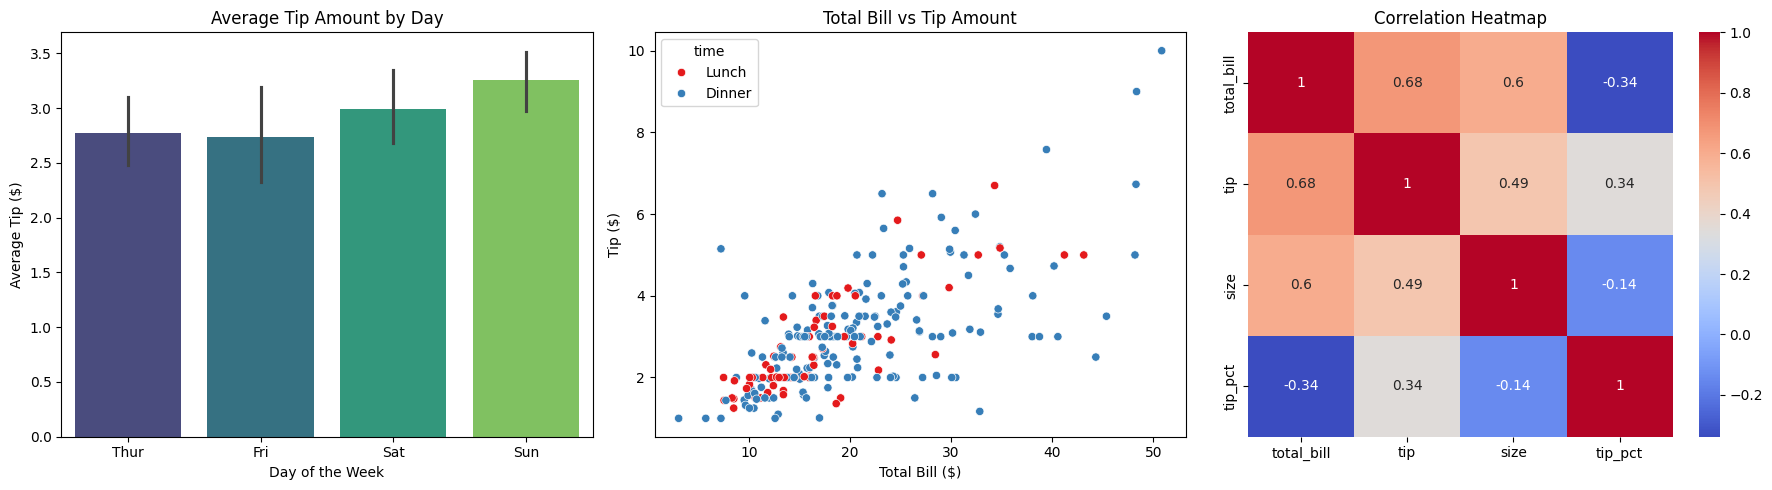

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1: Average Tip by Day (Bar Plot)
sns.barplot(x='day', y='tip', data=tips, ax=axes[0], palette='viridis')
axes[0].set_title('Average Tip Amount by Day')
axes[0].set_xlabel('Day of the Week')
axes[0].set_ylabel('Average Tip ($)')

# Chart 2: Total Bill vs Tip (Scatter Plot)
sns.scatterplot(x='total_bill', y='tip', hue='time', data=tips, ax=axes[1], palette='Set1')
axes[1].set_title('Total Bill vs Tip Amount')
axes[1].set_xlabel('Total Bill ($)')
axes[1].set_ylabel('Tip ($)')

# Chart 3: Correlation Heatmap
# Select only numerical columns for correlation
numeric_cols = tips.select_dtypes(include=[np.number])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', ax=axes[2])
axes[2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

## 5. Compute conditional probability and check for skewness

In [5]:
# Conditional Probability: P(Tip > 20% | Dinner time)
dinner_tips = tips[tips['time'] == 'Dinner']
prob_high_tip_given_dinner = (dinner_tips['tip_pct'] > 20).mean()
print(f"P(Tip > 20% | Dinner): {prob_high_tip_given_dinner:.2%}")

# Skewness check: Mean vs Median for 'total_bill'
mean_bill = tips['total_bill'].mean()
median_bill = tips['total_bill'].median()

print(f"\nTotal Bill - Mean: ${mean_bill:.2f}, Median: ${median_bill:.2f}")
if mean_bill > median_bill:
    print("The 'total_bill' is RIGHT-SKEWED (positive skew). This means a few very large bills are pulling the mean upwards.")
elif mean_bill < median_bill:
    print("The 'total_bill' is LEFT-SKEWED (negative skew).")
else:
    print("The 'total_bill' is perfectly symmetric.")

P(Tip > 20% | Dinner): 15.34%

Total Bill - Mean: $19.79, Median: $17.80
The 'total_bill' is RIGHT-SKEWED (positive skew). This means a few very large bills are pulling the mean upwards.


## 6. Insights
- **Insight 1 (Correlation):** The heatmap shows a strong positive correlation ($0.68$) between `total_bill` and `tip`—larger bills naturally yield larger tips. Interestingly, `tip_pct` is negatively correlated with `total_bill` ($-0.34$), meaning people tend to leave a slightly smaller *percentage* tip when the bill gets very high.
- **Insight 2 (Skewness):** The `total_bill` data is right-skewed. The average (mean) bill is roughly $\$21.28$, but the median is $\$17.80$. A few big spenders pull the average up, making the median a better representation of a "typical" bill.
- **Insight 3 (Group Behaviors):** Based on the `groupby` results, the average tip percentage stays remarkably consistent across different days of the week (~$15\%$-$16\%$). However, smaller parties (size 1) leave a higher percentage tip (~$21.7\%$) compared to very large parties (size 5 or 6, which leave ~$14\%$-$15\%$).